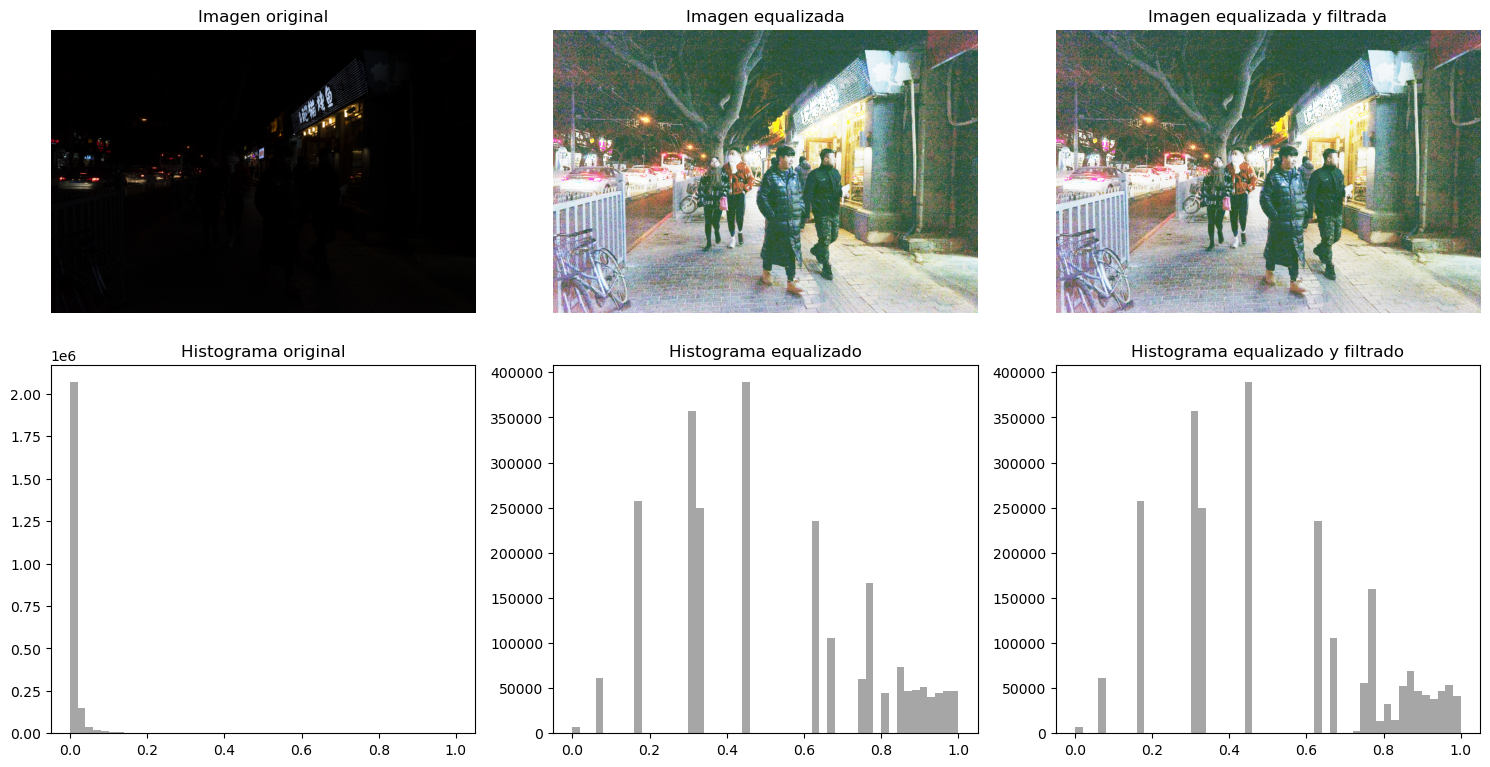

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure, img_as_float
from skimage.restoration import denoise_bilateral

# Cargar la imagen
image_path = "4.png"  # Reemplaza con tu ruta de archivo
image = io.imread(image_path)  # Cargar imagen a color
image = img_as_float(image)  # Normalizar a rango [0, 1]

# Aplicar equalización de histograma por canal
equalized_image = np.zeros_like(image)
for channel in range(image.shape[-1]):  # Iterar sobre cada canal
    equalized_image[..., channel] = exposure.equalize_hist(image[..., channel])

# Aplicar filtro bilateral a la imagen completa
bilateral_filtered_image = denoise_bilateral(
    equalized_image, sigma_color=0.01, sigma_spatial=10, channel_axis=-1
)

# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # Ajustar para 2 filas y 3 columnas

# Imagen original
axes[0, 0].imshow(image)
axes[0, 0].set_title("Imagen original")
axes[0, 0].axis("off")

# Histograma de la imagen original
axes[1, 0].hist(image.ravel(), bins=50, range=(0, 1), color="gray", alpha=0.7)
axes[1, 0].set_title("Histograma original")

# Imagen equalizada
axes[0, 1].imshow(equalized_image)
axes[0, 1].set_title("Imagen equalizada")
axes[0, 1].axis("off")

# Histograma de la imagen equalizada
axes[1, 1].hist(equalized_image.ravel(), bins=50, range=(0, 1), color="gray", alpha=0.7)
axes[1, 1].set_title("Histograma equalizado")

# Imagen filtrada
axes[0, 2].imshow(bilateral_filtered_image)
axes[0, 2].set_title("Imagen equalizada y filtrada")
axes[0, 2].axis("off")

# Histograma de la imagen filtrada
axes[1, 2].hist(bilateral_filtered_image.ravel(), bins=50, range=(0, 1), color="gray", alpha=0.7)
axes[1, 2].set_title("Histograma equalizado y filtrado")

plt.tight_layout()
plt.show()
